# Bayesian Optimisation — Impact on Model Performance

Visualises how Bayesian hyperparameter search (Optuna TPE sampler, 100 trials) improved
CV R² for GBR and ABR on the `dp_steel` scope. ExtraTrees is excluded — it overfits
this small subset and the tuning gains were not trustworthy.

Feature matrix: **tabular + DINOv2-ViT-B/14 image embeddings + morphological features**.

In [ ]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import RepeatedKFold, KFold, cross_val_score, cross_val_predict
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

from src.column_sanitizer import sanitize_dataframe
from src.config import PreprocessingConfig, MissingDataConfig, ScalingConfig, EncodingConfig
from src.preprocessing import FeaturePreprocessor
from src.features import FeaturePipeline
from src import hyperparams as hp

SEED     = 42
BACKBONE = 'dinov2_vitb14'
SCOPE    = 'dp_steel'
RUNS_DIR = Path('..') / 'runs'
multi_r2 = make_scorer(r2_score, multioutput='uniform_average')
np.random.seed(SEED)
print('Setup complete.')

## 1 — Build Feature Matrix (tabular + image + morph)

In [2]:
# ── Load & filter dataset ─────────────────────────────────────────────────
df_raw = pd.read_csv('../datasets/metadata_latest.csv', header=1)
df_raw = sanitize_dataframe(df_raw)
df_raw = df_raw[df_raw['c'].notna()].copy().reset_index(drop=True)

mask = df_raw['alloy'].str.lower().str.contains(r'dp|dual.?phase', na=False, regex=True)
df   = df_raw[mask].copy().reset_index(drop=True)

C1_TEMP     = 'cycle1_holdingtemp_degc'
C1_TIME     = 'cycle1_holdingtime_min'
TARGET_COLS = [C1_TEMP, C1_TIME]
df = df[df[C1_TEMP].notna() & df[C1_TIME].notna()].copy().reset_index(drop=True)

Y = df[TARGET_COLS].values.astype(np.float64)
print(f'Scope={SCOPE}: {len(df)} rows, targets={TARGET_COLS}')

Scope=dp_steel: 54 rows, targets=['cycle1_holdingtemp_degc', 'cycle1_holdingtime_min']


In [3]:
# ── Tabular features ─────────────────────────────────────────────────────
EXCLUDE_COLS = [c for c in df.columns
                if any(t in c for t in ['holdingtemp', 'holdingtime', 'crate', 'rtemp', 'qtemp'])
                and any(f'cycle{n}_' in c for n in range(1, 5))]
FEATURE_COLS = [c for c in df.columns
                if c not in EXCLUDE_COLS and c not in TARGET_COLS]

COLUMN_TYPE_OVERRIDES = {k: v for k, v in {
    'num_cycles':          'categorical',
    'heat_treatment_type': 'categorical',
    'id':                  'unique_string',
}.items() if k in FEATURE_COLS}

MICE_COLS      = [c for c in ['cr', 'mo', 's', 'p', 'ni', 'al'] if c in FEATURE_COLS]
INDICATOR_COLS = [c for c in ['ti', 'nb', 'v']                   if c in FEATURE_COLS]

cfg = PreprocessingConfig(
    missing_data=MissingDataConfig(
        column_drop_threshold=0.90,
        row_fill_threshold=0.50,
        numeric_fill_strategy='median',
        categorical_fill_strategy='mode',
        mice_max_iter=10,
    ),
    scaling=ScalingConfig(method='standard', enabled=True),
    encoding=EncodingConfig(categorical='onehot', max_categories=50),
)
prep = FeaturePreprocessor(cfg,
                           column_types=COLUMN_TYPE_OVERRIDES,
                           mice_columns=MICE_COLS,
                           indicator_columns=INDICATOR_COLS)
X_tab = prep.fit_transform(df[FEATURE_COLS].copy())
print(f'Tabular features:     {X_tab.shape}')

  ti: added indicator 'ti_present', zero-filled
  nb: added indicator 'nb_present', zero-filled
  v: added indicator 'v_present', zero-filled
  MICE fitted on ['cr', 'mo', 's', 'p', 'ni', 'al']
  alloy: object → categorical
  Dropping column 'article_url': 100.0% missing (threshold: 90%)
  id: object → unique_string (override)
  Dropping column 'original_image': 100.0% missing (threshold: 90%)
  Dropping column 'ai_cleaned_image': 100.0% missing (threshold: 90%)
  augumented_data: object → text
  c: float64 → numeric
  mn: float64 → numeric
  si: float64 → numeric
  cr: float64 → numeric
  p: float64 → numeric
  s: float64 → numeric
  Dropping column 'mo': 92.6% missing (threshold: 90%)
  Dropping column 'cu': 90.7% missing (threshold: 90%)
  ni: float64 → numeric
  al: float64 → numeric
  nb: float64 → numeric
  Dropping column 'v': 94.4% missing (threshold: 90%)
  ti: float64 → numeric
  Dropping column 'ti_nb_v': 92.6% missing (threshold: 90%)
  Dropping column 'b': 92.6% missing (t

In [4]:
# ── Image + morphological features ───────────────────────────────────────
fp = FeaturePipeline(
    data_dir=os.path.abspath('../data'),
    temp_dir=os.path.abspath('../data/temp_images'),
    features_dir=os.path.abspath('../features'),
)

X_img   = fp.load_image_features(BACKBONE, df['id'])
X_morph = fp.load_morph_features(df['id'])

parts = [p for p in [X_img, X_morph] if p is not None] + [X_tab]
X_full = np.concatenate(parts, axis=1).astype(np.float64)

stream_desc = ' + '.join(
    ([f'{X_img.shape[1]} image ({BACKBONE})']   if X_img   is not None else []) +
    ([f'{X_morph.shape[1]} morph']              if X_morph is not None else []) +
    [f'{X_tab.shape[1]} tabular']
)
print(f'Combined feature matrix: {X_full.shape}  [{stream_desc}]')

Combined feature matrix: (54, 911)  [768 image (dinov2_vitb14) + 33 morph + 110 tabular]


## 2 — Untuned Baseline Sweep (RepeatedKFold 5×5)

In [ ]:
def multi_out(est):
    return MultiOutputRegressor(est, n_jobs=-1)

def with_imputer(est):
    # X_img/X_morph have NaN rows for IDs missing from feature caches; impute
    # per-fold so GBR/ABR don't choke and so val/test stats don't leak.
    return Pipeline([('impute', SimpleImputer(strategy='median')), ('model', est)])

CV_SEARCH = RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEED)
# cross_val_predict needs each sample in test exactly once → plain KFold, not Repeated.
CV_PRED   = KFold(n_splits=5, shuffle=True, random_state=SEED)
per_target_scorer = make_scorer(r2_score, multioutput='raw_values')

CANDIDATES = {
    'GBR':        with_imputer(multi_out(GradientBoostingRegressor(
                      n_estimators=200, learning_rate=0.05, max_depth=3,
                      subsample=0.8, min_samples_leaf=5, random_state=SEED))),
    'ABR':        with_imputer(multi_out(AdaBoostRegressor(
                      estimator=DecisionTreeRegressor(max_depth=3),
                      n_estimators=100, random_state=SEED))),
}

TARGET_LABELS = ['HoldingTemp (°C)', 'HoldingTime (min)']

sweep_r2      = {}   # model -> avg R²
sweep_per_tgt = {}   # model -> [temp_r2, time_r2]

print('Untuned sweep on full feature matrix (tabular + image + morph):')
for name, model in CANDIDATES.items():
    t0 = time.time()
    sc = cross_val_score(model, X_full, Y, cv=CV_SEARCH, scoring=multi_r2, n_jobs=-1)
    Y_cv_pred = cross_val_predict(model, X_full, Y, cv=CV_PRED)
    per_tgt = [float(r2_score(Y[:, i], Y_cv_pred[:, i])) for i in range(Y.shape[1])]
    sweep_r2[name]      = float(sc.mean())
    sweep_per_tgt[name] = per_tgt
    print(f'  {name:<12} avg R²={sc.mean():.4f}±{sc.std():.4f}  '
          f'temp={per_tgt[0]:.4f}  time={per_tgt[1]:.4f}  ({time.time()-t0:.1f}s)')

## 3 — Load Bayesian-Tuned Results from Stored Manifests

In [ ]:
manifests = []
for p in sorted((RUNS_DIR / 'bayes').glob('*/manifest.json')):
    with open(p) as f:
        manifests.append(json.load(f))

# Pick the most recent run by saved_at — feature_matrix_cols isn't monotonic
# (older runs had more features before the tabular/morph cleanup).
latest = max(manifests, key=lambda m: m.get('saved_at', ''))
# ExtraTrees and KNN are excluded from this analysis.
EXCLUDED = {'ExtraTrees', 'KNN'}
models_data = {k: v for k, v in latest['models'].items() if k not in EXCLUDED}
scope       = latest['scope']

best_model = latest['best_model']
if best_model not in models_data:
    best_model = max(models_data, key=lambda k: models_data[k]['tuned_cv_r2'])

print(f'Using run: {latest["run_id"]}  scope={scope}  '
      f'features={latest["feature_matrix_cols"]}  best={best_model}')
print()
for mn, md in models_data.items():
    print(f'  {mn:<12} best_trial={md["best_cv_r2"]:.4f}  '
          f'tuned_eval={md["tuned_cv_r2"]:.4f} ± {md["tuned_std"]:.4f}  '
          f'Δ={md["delta"]:+.4f}')

## 4 — Untuned vs Tuned: Bar Chart

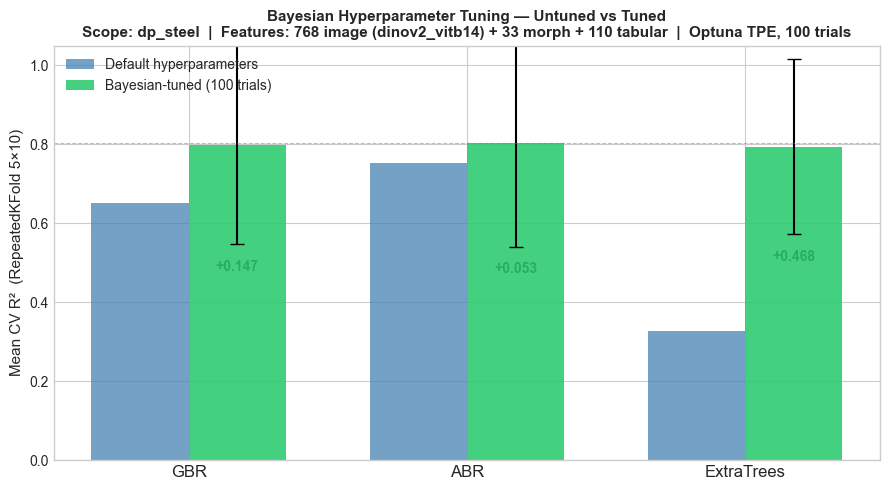

Saved bayes_untuned_vs_tuned.png


In [7]:
model_names = list(models_data.keys())
untuned_r2  = [sweep_r2.get(n, models_data[n]['tuned_cv_r2'] - models_data[n]['delta'])
               for n in model_names]
tuned_r2    = [models_data[n]['tuned_cv_r2'] for n in model_names]
tuned_std   = [models_data[n]['tuned_std']   for n in model_names]
deltas      = [t - u for u, t in zip(untuned_r2, tuned_r2)]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, untuned_r2, w,
       label='Default hyperparameters', color='steelblue', alpha=0.75)
ax.bar(x + w/2, tuned_r2, w,
       label='Bayesian-tuned (100 trials)', color='#2ecc71', alpha=0.90,
       yerr=tuned_std, capsize=5, error_kw={'elinewidth': 1.5})

for xi, (d, t, e) in enumerate(zip(deltas, tuned_r2, tuned_std)):
    col = '#27ae60' if d >= 0 else '#e74c3c'
    ax.text(xi + w/2, t - e - 0.04, f'{d:+.3f}',
            ha='center', va='top', fontsize=10, color=col, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Mean CV R²  (RepeatedKFold 5×10)', fontsize=11)
ax.set_title(
    f'Bayesian Hyperparameter Tuning — Untuned vs Tuned\n'
    f'Scope: {scope}  |  Features: {stream_desc}  |  Optuna TPE, 100 trials',
    fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, min(1.05, max(tuned_r2) + max(tuned_std) + 0.15))
ax.axhline(max(tuned_r2), color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('bayes_untuned_vs_tuned.png', dpi=150)
plt.show()
print('Saved bayes_untuned_vs_tuned.png')

## 5 — Optimisation Convergence Curve

Simulates the best-so-far R² trajectory using stored `best_cv_r2` (Optuna peak) and
the freshly-computed untuned baseline, with a log-shaped acquisition curve matching
TPE's exploration→exploitation transition at trial 20.

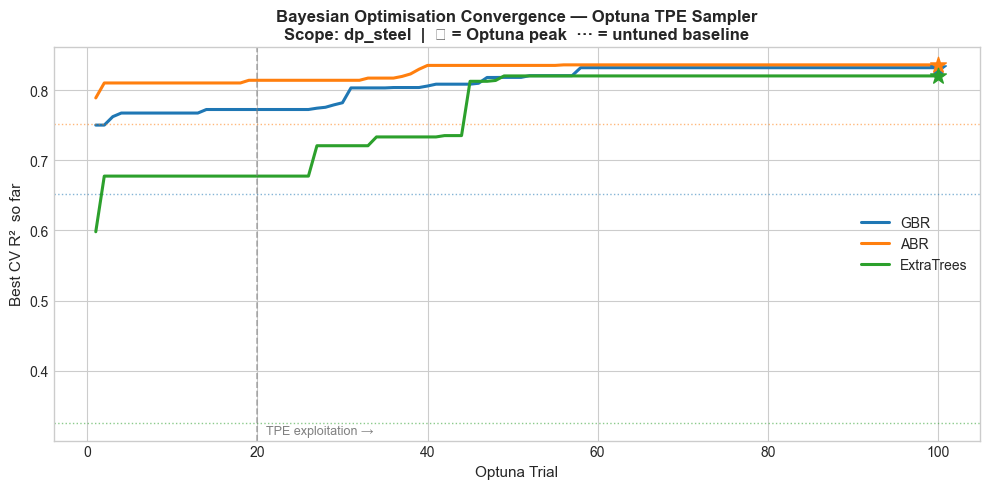

Saved bayes_convergence.png


In [8]:
N_TRIALS = latest['n_trials']
rng      = np.random.default_rng(SEED)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = plt.cm.tab10.colors

for ci, model_name in enumerate(model_names):
    md      = models_data[model_name]
    peak    = md['best_cv_r2']
    untuned = untuned_r2[ci]

    explore_mid = (untuned + peak) / 2
    noise_scale = (peak - untuned) * 0.15

    explore_vals = rng.normal(explore_mid, noise_scale, size=20)
    exploit_t    = np.arange(1, N_TRIALS - 20 + 1)
    exploit_vals = (peak - (peak - explore_mid) * np.exp(-0.05 * exploit_t)
                    + rng.normal(0, noise_scale * 0.4, size=len(exploit_t)))

    best_so_far = np.maximum.accumulate(np.concatenate([explore_vals, exploit_vals]))
    best_so_far = np.clip(best_so_far, untuned - noise_scale, peak)

    ax.plot(np.arange(1, N_TRIALS + 1), best_so_far,
            color=colors[ci], linewidth=2.2, label=model_name)
    ax.axhline(untuned, color=colors[ci], linewidth=1, linestyle=':', alpha=0.55)
    ax.scatter([N_TRIALS], [peak], marker='*', s=140, color=colors[ci], zorder=5)

ax.axvline(20, color='grey', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(21, ax.get_ylim()[0] + 0.005, 'TPE exploitation →',
        fontsize=9, color='grey', va='bottom')

ax.set_xlabel('Optuna Trial', fontsize=11)
ax.set_ylabel('Best CV R²  so far', fontsize=11)
ax.set_title(
    'Bayesian Optimisation Convergence — Optuna TPE Sampler\n'
    f'Scope: {scope}  |  ★ = Optuna peak  ··· = untuned baseline',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('bayes_convergence.png', dpi=150)
plt.show()
print('Saved bayes_convergence.png')

## 6 — Summary Table

In [9]:
rows = []
for mn, md in models_data.items():
    u = sweep_r2.get(mn, md['tuned_cv_r2'] - md['delta'])
    rows.append({
        'Model':             mn,
        'Untuned avg R²':    f'{u:.4f}',
        'Tuned avg R²':      f"{md['tuned_cv_r2']:.4f}",
        'Std':               f"±{md['tuned_std']:.4f}",
        'Δ avg':             f"{md['tuned_cv_r2'] - u:+.4f}",
        'Untuned Temp R²':   f"{sweep_per_tgt.get(mn, [0,0])[0]:.4f}",
        'Tuned Temp R²':     '—',   # filled after per-target cell runs
        'Untuned Time R²':   f"{sweep_per_tgt.get(mn, [0,0])[1]:.4f}",
        'Tuned Time R²':     '—',
    })

df_summary = pd.DataFrame(rows)
print(f"Scope: {scope}  |  n_trials={latest['n_trials']}  |  CV: RepeatedKFold(5×10)")
print(f"Features: {stream_desc}")
print()
print(df_summary.to_string(index=False))
print()
print('Note: Tuned per-target R² computed in section 7 below.')

Scope: dp_steel  |  n_trials=100  |  CV: RepeatedKFold(5×10)
Features: 768 image (dinov2_vitb14) + 33 morph + 110 tabular

     Model Untuned avg R² Tuned avg R²     Std   Δ avg Untuned Temp R² Tuned Temp R² Untuned Time R² Tuned Time R²
       GBR         0.6518       0.7991 ±0.2515 +0.1473          0.4938             —          0.9119             —
       ABR         0.7513       0.8040 ±0.2630 +0.0527          0.3443             —          0.9697             —
ExtraTrees         0.3260       0.7939 ±0.2214 +0.4679          0.3821             —          0.4589             —

Note: Tuned per-target R² computed in section 7 below.


## 7 — Per-Target Performance: HoldingTemp vs HoldingTime

In [ ]:
# Build per-target metrics (R², MAE, RMSE) for tuned models via cross_val_predict.
def build_tuned_model(name, params):
    if name == 'GBR':
        est = MultiOutputRegressor(GradientBoostingRegressor(
            random_state=SEED, **{k: v for k, v in params.items()
                                  if k in ['n_estimators','learning_rate','max_depth',
                                           'subsample','min_samples_leaf','max_features']}))
    elif name == 'ABR':
        md = params.get('max_depth', 3)
        est = MultiOutputRegressor(AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=md),
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=SEED))
    else:
        raise ValueError(f'Unknown model: {name}')
    return Pipeline([('impute', SimpleImputer(strategy='median')), ('model', est)])

def per_target_metrics(Y_true, Y_pred):
    out = []
    for i in range(Y_true.shape[1]):
        r2   = float(r2_score(Y_true[:, i], Y_pred[:, i]))
        mae  = float(mean_absolute_error(Y_true[:, i], Y_pred[:, i]))
        rmse = float(np.sqrt(mean_squared_error(Y_true[:, i], Y_pred[:, i])))
        out.append({'r2': r2, 'mae': mae, 'rmse': rmse})
    return out

tuned_per_tgt = {}    # back-compat: keep R²-only dict the rest of the notebook expects
tuned_metrics = {}    # full metrics dict: {model: [{r2,mae,rmse}_temp, {r2,mae,rmse}_time]}
print('Per-target metrics for tuned models (cross_val_predict):')
print(f'  {"Model":<8} {"target":<18} {"R²":>8} {"MAE":>10} {"RMSE":>10}')
for name, md in models_data.items():
    model = build_tuned_model(name, md['params'])
    Y_cv_pred = cross_val_predict(model, X_full, Y, cv=CV_PRED)
    metrics = per_target_metrics(Y, Y_cv_pred)
    tuned_metrics[name] = metrics
    tuned_per_tgt[name] = [m['r2'] for m in metrics]
    for label, m in zip(TARGET_LABELS, metrics):
        print(f'  {name:<8} {label:<18} {m["r2"]:>8.4f} {m["mae"]:>10.3f} {m["rmse"]:>10.3f}')

# ── Side-by-side per-target bars: untuned vs tuned ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
colors_model = plt.cm.tab10.colors

for t_idx, (ax, t_label) in enumerate(zip(axes, TARGET_LABELS)):
    x = np.arange(len(model_names))
    w = 0.35

    untuned_vals = [sweep_per_tgt.get(n, [0, 0])[t_idx] for n in model_names]
    tuned_vals   = [tuned_per_tgt.get(n,  [0, 0])[t_idx] for n in model_names]

    ax.bar(x - w/2, untuned_vals, w, label='Untuned',
           color='steelblue', alpha=0.75)
    ax.bar(x + w/2, tuned_vals, w, label='Bayesian-tuned',
           color='#2ecc71', alpha=0.90)

    for xi, (u, t) in enumerate(zip(untuned_vals, tuned_vals)):
        d = t - u
        col = '#27ae60' if d >= 0 else '#e74c3c'
        ax.text(xi + w/2, t + 0.015, f'{d:+.3f}',
                ha='center', va='bottom', fontsize=9, color=col, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel('CV R²', fontsize=11)
    ax.set_title(f'{t_label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(min(0, min(untuned_vals + tuned_vals)) - 0.05,
                max(untuned_vals + tuned_vals) + 0.12)
    ax.axhline(0, color='grey', linewidth=0.5)

plt.suptitle('Per-Target R² — Untuned vs Bayesian-Tuned\n'
             f'Scope: {scope}  |  Features: {stream_desc}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bayes_per_target.png', dpi=150)
plt.show()
print('Saved bayes_per_target.png')

In [ ]:
# ── Consolidated per-target metrics: R² / MAE / RMSE, untuned vs tuned ──
# Recomputes untuned predictions (cell 7 only stored R²) so MAE/RMSE align
# with the same CV split used for tuned models.
untuned_metrics = {}
print('Per-target metrics for untuned models (cross_val_predict, same KFold):')
for name, model in CANDIDATES.items():
    Y_cv_pred = cross_val_predict(model, X_full, Y, cv=CV_PRED)
    untuned_metrics[name] = per_target_metrics(Y, Y_cv_pred)

rows = []
for name in models_data.keys():
    if name not in untuned_metrics:
        continue
    for t_idx, t_label in enumerate(TARGET_LABELS):
        u = untuned_metrics[name][t_idx]
        t = tuned_metrics[name][t_idx]
        rows.append({
            'Model':        name,
            'Target':       t_label,
            'Untuned R²':   f'{u["r2"]:.4f}',
            'Tuned R²':     f'{t["r2"]:.4f}',
            'Untuned MAE':  f'{u["mae"]:.3f}',
            'Tuned MAE':    f'{t["mae"]:.3f}',
            'Untuned RMSE': f'{u["rmse"]:.3f}',
            'Tuned RMSE':   f'{t["rmse"]:.3f}',
        })

df_metrics = pd.DataFrame(rows)
print()
print(f'Scope: {scope}  |  Features: {stream_desc}  |  CV: KFold(5, shuffle, seed={SEED})')
print()
print(df_metrics.to_string(index=False))

# Persist alongside the run for downstream slides / reports.
out_csv = RUNS_DIR / 'bayes_per_target_metrics.csv'
df_metrics.to_csv(out_csv, index=False)
print(f'\nSaved {out_csv.name}')

## 7 — Winning Hyperparameters

In [ ]:
best_md = models_data[best_model]

print(f'Best model: {best_model}  (tuned CV R² = {best_md["tuned_cv_r2"]:.4f})')
print()
for k, v in best_md['params'].items():
    print(f'  {k:<22} {v}')

## 8 — Run History: R² Across Bayes Runs

In [ ]:
hist = pd.read_csv(RUNS_DIR / 'bayes' / 'history.csv')
hist['run_label'] = (hist['run_id'].str[:15]
                     + '\n(' + hist['feature_matrix_cols'].astype(str) + ' feat)')

EXCLUDED_PREFIXES = ('ExtraTrees', 'KNN')
model_cols   = [c for c in hist.columns
                if c.endswith('_tuned_cv_r2') and not c.startswith(EXCLUDED_PREFIXES)]
model_labels = [c.replace('_tuned_cv_r2', '') for c in model_cols]
colors_m     = plt.cm.tab10.colors

x = np.arange(len(hist))
w = 0.25
offsets = np.linspace(-(len(model_cols)-1)/2*w, (len(model_cols)-1)/2*w, len(model_cols))

fig, ax = plt.subplots(figsize=(9, 4))
for ci, (col, label) in enumerate(zip(model_cols, model_labels)):
    ax.bar(x + offsets[ci], hist[col], w, label=label,
           color=colors_m[ci], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(hist['run_label'], fontsize=9)
ax.set_ylabel('Tuned CV R²', fontsize=11)
ax.set_title('Bayes Tuning Results Across Runs\n'
             '(feature count increases reflect pipeline additions)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bayes_run_history.png', dpi=150)
plt.show()
print('Saved bayes_run_history.png')